# join_all

Join & run pipeline on all tables.

In [1]:
# Join all tables that don't need pivoting

import duckdb
from pathlib import Path
import pandas as pd
import numpy as np

non_pivot_tables = ["ic", "ic_ay", "ic_py", "adm", "efia", "ef_d", "sfa", "gr200", "al", "f1a", "f2", "f3"]

pivot_tables = ['effy', 'ef_a', 'ef_b', 'ef_c', 'gr', 'om', 'eap', 'sal_is']
ignore_cols = {
    'effy': ['effyalev', 'effylev', 'lstudy'],
    'ef_a': ['unitid', 'efalevel', 'line', 'section', 'lstudy'],
    'ef_b': ['efbage', 'line', 'lstudy'],
    'ef_c': ['efcstate', 'line'],
    'gr': ['grtype', 'chrtstat', 'section', 'cohort', 'line'],
    'om': ['omchrt'],
    'eap': ['eapcat', 'occupcat', 'facstat', 'xeaptot', 'eaptot'],
    'sal_is': ['arank']
}
pivot_cols = {
    'effy': ['effyalev'],
    'ef_a': ['efalevel'],
    'ef_b': ['efbage', 'lstudy'],
    'ef_c': ['efcstate'],
    'gr': ['grtype'],
    'om': ['omchrt'],
    'eap': ['eapcat'],
    'sal_is': ['arank']
}

current_script_parent = Path.cwd().parent
con = duckdb.connect(current_script_parent / "ipeds.duckdb")

def get_cleaned_table(table_name):
    query = f"""SELECT * FROM {table_name} WHERE year = 2023""".format(table_name=table_name)
    table_df = con.execute(query).fetchdf()
    table_df = table_df.select_dtypes(include=[np.number])
    table_df = table_df.replace('.', np.nan)
    table_df = table_df.dropna(axis=1, how='all')
    return table_df

In [2]:
db = con.execute("SELECT * FROM hd WHERE year = 2023").fetchdf()

for table in non_pivot_tables:
    print(f"Processing table: {table}")
    table_df = get_cleaned_table(table)
    db = db.merge(table_df, on=["unitid", "year"], how="left")

for table in pivot_tables:
    print(f"Processing pivot table: {table}")

    table_df = get_cleaned_table(table)

    exclude_cols = ignore_cols[table]
    data_cols = [col for col in table_df.columns if col not in exclude_cols]

    pivot_df = table_df.pivot(
        index='unitid',
        columns=pivot_cols[table],
        values=data_cols
    )

    # rename pivoted cols
    new_col_names = []
    for i, col in enumerate(pivot_df.columns):
        new_name = f"{pivot_df.columns[i][0]}_"

        for j, label in enumerate(pivot_cols[table]):
            new_name += f"_{label}_{pivot_df.columns[i][j+1]}"

        new_col_names.append(new_name)
    pivot_df.columns = new_col_names

    db = db.merge(pivot_df, on=["unitid"], how="left")


Processing table: ic
Processing table: ic_ay
Processing table: ic_py
Processing table: adm
Processing table: efia
Processing table: ef_d
Processing table: sfa
Processing table: gr200
Processing table: al
Processing table: f1a
Processing table: f2
Processing table: f3
Processing pivot table: effy
Processing pivot table: ef_a
Processing pivot table: ef_b
Processing pivot table: ef_c
Processing pivot table: gr
Processing pivot table: om
Processing pivot table: eap
Processing pivot table: sal_is


Imputation Strategy: mean


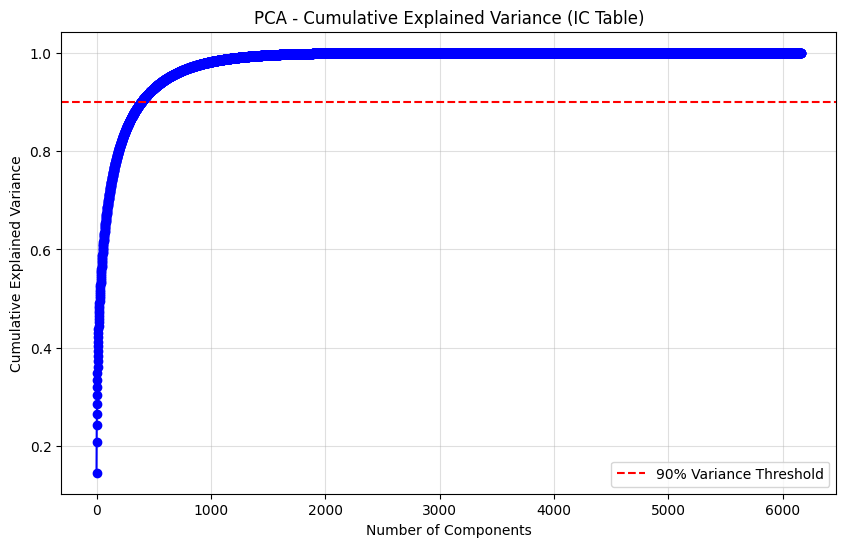

Imputation Strategy: 0


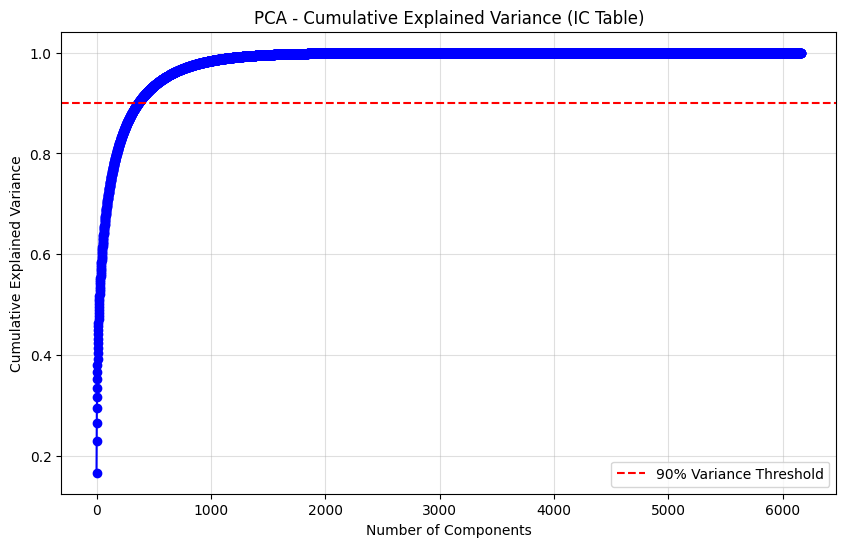

Imputation Strategy: delete


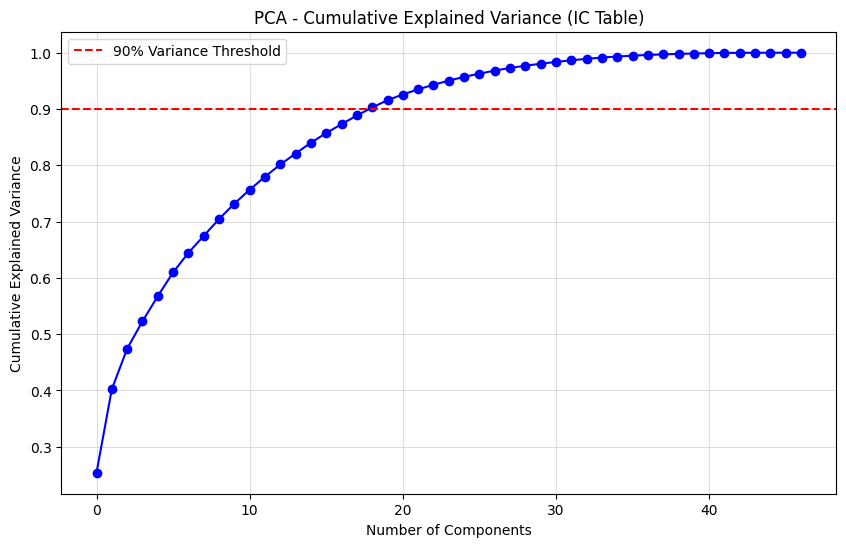

In [ ]:
db = db.dropna(axis=1, how='all')

for imputation_strategy in ["mean", "0", "delete"]:

    if imputation_strategy == "mean":
        db_cleaned = db.fillna(db.mean(numeric_only=True))
    elif imputation_strategy == "0":
        db_cleaned = db.fillna(0)
    elif imputation_strategy == "delete":
        db_cleaned = db.dropna(axis=1)

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    nan_counts = db_cleaned.isna().sum()
    nan_percentage = (nan_counts / len(db_cleaned)) * 100

    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    # Isolate numeric columns for PCA (exclude IDs and text metadata)
    cols_to_exclude = ['unitid', 'year', 'institution_name', 'city', 'state', 'carnegie', 'sector', 'control']
    numeric_cols = [col for col in db_cleaned.columns if col not in cols_to_exclude and pd.api.types.is_numeric_dtype(db_cleaned[col])]

    X = db_cleaned[numeric_cols].copy()

    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit the PCA
    pca = PCA()
    df_pca = pca.fit_transform(X_scaled)

    print(f"Imputation Strategy: {imputation_strategy}")

    # lot the Cumulative Explained Variance
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='b')
    plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA - Cumulative Explained Variance (IC Table)')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

    del X, db_cleaned, X_scaled, df_pca

In [8]:
import plotly.express as px

# Plot 2D PCA with highlighted institutions

# Define the institutions to highlight by unitid 
highlight_unitids = [196866, # Union
                     165015, # Brandeis
                     196079, # Binghamton
                     194824, # RPI
                     195474, # Siena
                     195164, # Saint Bonaventure
                     191719, # HVCC
                     190150] # Columbia University

db_cleaned = db.fillna(0)

cols_to_exclude = ['unitid', 'year', 'institution_name', 'city', 'state', 'carnegie', 'sector', 'control']
numeric_cols = [col for col in db_cleaned.columns if col not in cols_to_exclude and pd.api.types.is_numeric_dtype(db_cleaned[col])]

X = db_cleaned[numeric_cols].copy()

X = db_cleaned[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

db['PC1'] = X_pca_2d[:, 0]
db['PC2'] = X_pca_2d[:, 1]

db['Peer_Group'] = 'All Other Institutions'
db['Marker_Size'] = 5 

highlight_mask = db['unitid'].isin(highlight_unitids)
db.loc[highlight_mask, 'Peer_Group'] = db['institution_name']
db.loc[highlight_mask, 'Marker_Size'] = 15

db = db.sort_values('Marker_Size')

fig = px.scatter(
    db,
    x='PC1',
    y='PC2',
    color='Peer_Group',
    size='Marker_Size', 
    size_max=15,       
    hover_name='institution_name',
    hover_data={
        'PC1': False,          
        'PC2': False,         
        'Peer_Group': False,  
        'Marker_Size': False,  
        'unitid': True,       
    },
    color_discrete_map={
        'All Other Institutions': 'lightgray'
    },
    title='2D Institutional Landscape (Hover for Details)',
    labels={
        'PC1': f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)',
        'PC2': f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)'
    }
)

fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', scaleratio=1),
    yaxis=dict(showgrid=True, gridcolor='lightgray', scaleratio=1),
)

fig.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
from sklearn.metrics import accuracy_score, f1_score

# Restore df_cleaned to its original order before joining NumPy arrays!
df_cleaned = db_cleaned.sort_index()

# --- Configuration ---
target_unitids = [195474]
m_components = 38                  
n_peers = 15                      

# Run PCA with m dimensions
pca_m = PCA(n_components=m_components)
X_pca_m = pca_m.fit_transform(X_scaled)

# Find the "Centroid" of the target institutions in PCA space
# Get the row indices of our targets in the dataframe
target_indices = df_cleaned.index[df_cleaned['unitid'].isin(target_unitids)].tolist()

# Calculate the mean position of our targets across all m dimensions
centroid = X_pca_m[target_indices].mean(axis=0).reshape(1, -1)

# Find the n closest institutions to the centroid
knn = NearestNeighbors(n_neighbors=n_peers + len(target_unitids))
knn.fit(X_pca_m)
distances, indices = knn.kneighbors(centroid)

# Flatten the list of nearest neighbor indices
peer_indices = indices[0]

# Create the Machine Learning Dataset
df_ml = df_cleaned.copy()
df_ml['peer'] = 0 # Default everyone to 0

# Set the identified nearest neighbors to 1
df_ml.iloc[peer_indices, df_ml.columns.get_loc('peer')] = 1

# Let's peek at who the model selected!
selected_peers = df_ml[df_ml['peer'] == 1][['unitid', 'institution_name']]
print(f"--- Top {len(selected_peers)} Peers Identified ---")
print(selected_peers.to_string(index=False))
print("\n")

# Train the "Explainer" Decision Tree
tree_X = df_ml[numeric_cols]
tree_y = df_ml['peer']

# Max_depth=2 keeps it "heavily pruned"
clf = DecisionTreeClassifier(max_depth=2, class_weight='balanced', random_state=42)
clf.fit(tree_X, tree_y)

plt.figure(figsize=(12, 8))
tree.plot_tree(clf, 
               feature_names=numeric_cols,  
               class_names=['Not a Peer', 'Peer'], # <-- Fixed class names!
               filled=True,
               rounded=True,       # Rounds the corners of the boxes
               proportion=False,   # Change to True if you want percentages instead of decimal weights
               fontsize=10)
plt.show()

y_pred = clf.predict(tree_X)
y_true = tree_y

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {acc}")
print(f"F1 Score: {f1}")